# ST-GCN - isolated single-variable ablation

Every regularization test so far bundled tcn_dropout + label_smoothing + higher augmentation probability + weight_decay together - we know the *combination* over- or under-shot on different runs, but not which single change actually did what. This isolates each one on top of the proven baseline (advanced augmentation, StepLR, checkpoint selected by val_top1 - still the strongest all-around result so far).

Four runs, same architecture and schedule throughout, exactly one thing changed per run:
1. **baseline_repeat** - same config as the winning run, different seed. Tells us how much these numbers move from pure noise before trusting any "improvement" as real.
2. **label_smoothing_only** - 0.1, nothing else changed
3. **tcn_dropout_only** - 0.15 (lower than the 0.25 tried combined, which may have been the overshoot)
4. **weight_decay_only** - 1e-3, up from the baseline's 5e-4

This will take longer than any single run so far (roughly 4x) - genuinely fine given there's no rush, and clean isolated evidence is worth more than another blind guess.

### determinism - before torch touches CUDA

In [1]:
import os
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

import sys
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score, top_k_accuracy_score

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

sys.path.insert(0, "/workspace/badminton-honours-project")
import dataset as ds

import mmaction.models  # noqa: F401
from mmaction.utils import register_all_modules
register_all_modules()
from mmaction.registry import MODELS

from clearml import Task

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("device:", device)


device: cuda:0


### paths

In [2]:
OUT_ROOT = "/workspace/outputs/stgcn_ablation"
CKPT_ROOT = "/workspace/checkpoints/stgcn_ablation"
os.makedirs(OUT_ROOT, exist_ok=True)
os.makedirs(CKPT_ROOT, exist_ok=True)


### data - advanced augmentation, matching the proven baseline

In [3]:
manifest = ds.load_filtered_manifest(
    "/workspace/data/split_manifest.csv",
    "/workspace/data/extraction_log.csv",
)

class_names = sorted(manifest["class_name"].unique())
class_to_id = {name: i for i, name in enumerate(class_names)}
num_classes = len(class_names)

train_manifest = manifest[manifest["split"] == "train"].reset_index(drop=True)
val_manifest = manifest[manifest["split"] == "val"].reset_index(drop=True)
test_manifest = manifest[manifest["split"] == "test"].reset_index(drop=True)

KEYPOINTS_ROOT = "/workspace/data/keypoints_smoothed"

train_ds = ds.BadmintonPoseDataset(train_manifest, KEYPOINTS_ROOT, class_to_id, augmentation_policy="advanced")
val_ds = ds.BadmintonPoseDataset(val_manifest, KEYPOINTS_ROOT, class_to_id)
test_ds = ds.BadmintonPoseDataset(test_manifest, KEYPOINTS_ROOT, class_to_id)

balanced_sampler = ds.build_class_balanced_sampler(train_manifest, target_per_class=500, seed=42)

val_loader = DataLoader(val_ds, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)

print(f"{num_classes} classes, train {len(train_manifest)}, val {len(val_ds)}, test {len(test_ds)}")


dropped 4 manually-excluded clips from the manifest (7814 remain)
18 classes, train 6251, val 781, test 782


### batch -> ST-GCN input, metrics - unchanged from every prior run

In [4]:
def batch_to_stgcn_input(batch):
    kp = batch["keypoints"].float()
    x = kp.unsqueeze(1).unsqueeze(1)
    return x


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_labels, all_preds, all_probs = [], [], []
    for batch in loader:
        x = batch_to_stgcn_input(batch).to(device)
        y = batch["label"].to(device)
        logits = model(x, mode="tensor", stage="head")
        probs = torch.softmax(logits, dim=1)
        all_labels.append(y.cpu().numpy())
        all_preds.append(probs.argmax(dim=1).cpu().numpy())
        all_probs.append(probs.cpu().numpy())
    labels = np.concatenate(all_labels)
    preds = np.concatenate(all_preds)
    probs = np.concatenate(all_probs)
    return {
        "top1": accuracy_score(labels, preds),
        "top5": top_k_accuracy_score(labels, probs, k=5, labels=list(range(num_classes))),
        "mca": balanced_accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
        "labels": labels, "preds": preds,
    }


### the reusable training function

Same 9-stage architecture, same StepLR schedule, same top1-based checkpoint selection every time - only `tcn_dropout`, `label_smoothing`, `weight_decay`, and `seed` vary between calls, matching exactly one isolated change per config.

In [5]:
def train_one_config(config_name, seed=42, tcn_dropout=0.0, label_smoothing=0.0,
                      weight_decay=5e-4, num_epochs=60, patience=20, batch_size=16, lr=0.01):
    torch.manual_seed(seed)
    np.random.seed(seed)

    model_cfg = dict(
        type="RecognizerGCN",
        backbone=dict(
            type="STGCN",
            graph_cfg=dict(layout="coco", mode="stgcn_spatial"),
            in_channels=3, base_channels=64, ch_ratio=2,
            num_stages=9, inflate_stages=[4, 7], down_stages=[4, 7],
            tcn_dropout=tcn_dropout,
        ),
        cls_head=dict(type="GCNHead", num_classes=num_classes, in_channels=256,
                      loss_cls=dict(type="CrossEntropyLoss")),
    )
    model = MODELS.build(model_cfg).to(device)

    train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=balanced_sampler,
                               num_workers=4, pin_memory=True, persistent_workers=True)

    task = Task.init(project_name="BadmintonPoseAnalysis", task_name=f"stgcn_ablation_{config_name}", reuse_last_task_id=False)
    logger = task.get_logger()
    task.connect({
        "config_name": config_name, "seed": seed, "tcn_dropout": tcn_dropout,
        "label_smoothing": label_smoothing, "weight_decay": weight_decay,
        "lr": lr, "batch_size": batch_size,
    })

    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

    history = {"train_loss": [], "train_acc": [], "val_top1": [], "val_mca": []}
    best_val_top1 = 0.0
    epochs_without_improvement = 0
    best_state = None

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        epoch_labels, epoch_preds = [], []

        for batch in train_loader:
            x = batch_to_stgcn_input(batch).to(device)
            y = batch["label"].to(device)
            optimizer.zero_grad()
            logits = model(x, mode="tensor", stage="head")
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * x.size(0)
            epoch_labels.append(y.cpu().numpy())
            epoch_preds.append(logits.argmax(dim=1).cpu().numpy())

        scheduler.step()

        train_loss = epoch_loss / len(train_loader.dataset)
        train_acc = accuracy_score(np.concatenate(epoch_labels), np.concatenate(epoch_preds))
        val_metrics = evaluate(model, val_loader)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_top1"].append(val_metrics["top1"])
        history["val_mca"].append(val_metrics["mca"])

        logger.report_scalar("loss", "train", train_loss, iteration=epoch)
        logger.report_scalar("accuracy", "val_top1", val_metrics["top1"], iteration=epoch)

        if val_metrics["top1"] > best_val_top1:
            best_val_top1 = val_metrics["top1"]
            epochs_without_improvement = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            epochs_without_improvement += 1

        if epoch % 10 == 0 or epoch == num_epochs - 1:
            print(f"[{config_name}] epoch {epoch:3d}  train_acc={train_acc:.4f}  "
                  f"val_top1={val_metrics['top1']:.4f}  val_mca={val_metrics['mca']:.4f}")

        if epochs_without_improvement >= patience:
            print(f"[{config_name}] early stopping at epoch {epoch}, best val_top1={best_val_top1:.4f}")
            break

    model.load_state_dict(best_state)

    train_final = evaluate(model, DataLoader(train_ds, batch_size=64, shuffle=False, num_workers=4, pin_memory=True))
    val_final = evaluate(model, val_loader)
    test_final = evaluate(model, test_loader)

    metrics = {
        "config_name": config_name,
        "train_acc": train_final["top1"],
        "test_top1": test_final["top1"],
        "test_top5": test_final["top5"],
        "test_mca": test_final["mca"],
        "test_macro_f1": test_final["macro_f1"],
        "train_test_gap": train_final["top1"] - test_final["top1"],
    }

    ckpt_path = os.path.join(CKPT_ROOT, f"{config_name}_best.pt")
    torch.save(model.state_dict(), ckpt_path)
    task.upload_artifact("checkpoint", ckpt_path)
    task.upload_artifact("metrics", metrics)
    task.close()

    return metrics, history


### run all four configs

This is the long cell - roughly 4x a single run. Genuinely fine to leave unattended, same as every extraction/training job in this project.

In [6]:
configs = [
    {"config_name": "baseline_repeat",    "seed": 123, "tcn_dropout": 0.0,  "label_smoothing": 0.0, "weight_decay": 5e-4},
    {"config_name": "label_smoothing_only", "seed": 42, "tcn_dropout": 0.0,  "label_smoothing": 0.1, "weight_decay": 5e-4},
    {"config_name": "tcn_dropout_only",      "seed": 42, "tcn_dropout": 0.15, "label_smoothing": 0.0, "weight_decay": 5e-4},
    {"config_name": "weight_decay_only",     "seed": 42, "tcn_dropout": 0.0,  "label_smoothing": 0.0, "weight_decay": 1e-3},
]

all_results = {}
all_histories = {}

for cfg in configs:
    print(f"\n=== training {cfg['config_name']} ===")
    metrics, history = train_one_config(**cfg)
    all_results[cfg["config_name"]] = metrics
    all_histories[cfg["config_name"]] = history
    print(f"[{cfg['config_name']}] FINAL: test_top1={metrics['test_top1']:.4f}  "
          f"gap={metrics['train_test_gap']:.4f}  test_mca={metrics['test_mca']:.4f}  "
          f"test_macro_f1={metrics['test_macro_f1']:.4f}")



=== training baseline_repeat ===
ClearML Task: created new task id=7edd7b7d5e5a4a2dba5c67aeda243466
2026-09-10 05:19:33,148 - clearml.Repository Detection - WARNING - Failed accessing the jupyter server(s): []
ClearML results page: https://app.clear.ml/projects/89838577f7964905a3b492353933fcb2/tasks/7edd7b7d5e5a4a2dba5c67aeda243466/output/log
[baseline_repeat] epoch   0  train_acc=0.3028  val_top1=0.5211  val_mca=0.4079
[baseline_repeat] epoch  10  train_acc=0.8221  val_top1=0.6978  val_mca=0.6501
[baseline_repeat] epoch  20  train_acc=0.9393  val_top1=0.7119  val_mca=0.6289
[baseline_repeat] epoch  30  train_acc=0.9596  val_top1=0.7311  val_mca=0.6302
[baseline_repeat] epoch  40  train_acc=0.9592  val_top1=0.7260  val_mca=0.6336
[baseline_repeat] early stopping at epoch 47, best val_top1=0.7324


███████████████████████████████ 100% | 11.66/11.66 MB [00:01<00:00,  7.06MB/s]: 


[baseline_repeat] FINAL: test_top1=0.7020  gap=0.2802  test_mca=0.6017  test_macro_f1=0.6233

=== training label_smoothing_only ===


Failed accessing the jupyter server(s): []


ClearML Task: created new task id=f275ea333efd49b3b77db42ab5b41b0c
ClearML results page: https://app.clear.ml/projects/89838577f7964905a3b492353933fcb2/tasks/f275ea333efd49b3b77db42ab5b41b0c/output/log
[label_smoothing_only] epoch   0  train_acc=0.3079  val_top1=0.5378  val_mca=0.4110
[label_smoothing_only] epoch  10  train_acc=0.8522  val_top1=0.7093  val_mca=0.6322
[label_smoothing_only] epoch  20  train_acc=0.9590  val_top1=0.7209  val_mca=0.6357
[label_smoothing_only] epoch  30  train_acc=0.9754  val_top1=0.7311  val_mca=0.6268
[label_smoothing_only] epoch  40  train_acc=0.9778  val_top1=0.7196  val_mca=0.6272
[label_smoothing_only] epoch  50  train_acc=0.9743  val_top1=0.7324  val_mca=0.6285
[label_smoothing_only] epoch  59  train_acc=0.9756  val_top1=0.7273  val_mca=0.6282
[label_smoothing_only] early stopping at epoch 59, best val_top1=0.7324


...

[tcn_dropout_only] FINAL: test_top1=0.6880  gap=0.2231  test_mca=0.5933  test_macro_f1=0.6003

=== training weight_decay_only ===


Failed accessing the jupyter server(s): []


ClearML Task: created new task id=feebb6d982874eedac32db147ffc68ab
ClearML results page: https://app.clear.ml/projects/89838577f7964905a3b492353933fcb2/tasks/feebb6d982874eedac32db147ffc68ab/output/log
[weight_decay_only] epoch   0  train_acc=0.3027  val_top1=0.4289  val_mca=0.3809
[weight_decay_only] epoch  10  train_acc=0.7990  val_top1=0.6773  val_mca=0.6185
[weight_decay_only] epoch  20  train_acc=0.9251  val_top1=0.7196  val_mca=0.6370
[weight_decay_only] epoch  30  train_acc=0.9516  val_top1=0.7311  val_mca=0.6374
[weight_decay_only] epoch  40  train_acc=0.9518  val_top1=0.7234  val_mca=0.6246
[weight_decay_only] early stopping at epoch 45, best val_top1=0.7324


███████████████████████████████ 100% | 11.66/11.66 MB [00:01<00:00,  8.18MB/s]: 


[weight_decay_only] FINAL: test_top1=0.7148  gap=0.2489  test_mca=0.6304  test_macro_f1=0.6413


### comparison table

In [7]:
PREVIOUS_BASELINE = {
    "config_name": "original_winning_run", "train_acc": 0.9187, "test_top1": 0.7072,
    "test_top5": 0.9335, "test_mca": 0.6155, "test_macro_f1": 0.6309, "train_test_gap": 0.2116,
}
LI_ET_AL_BENCHMARK = {
    "config_name": "Li et al. benchmark", "test_top1": 0.7441, "test_top5": 0.9376, "test_mca": 0.6144,
}

comparison = pd.DataFrame(list(all_results.values()) + [PREVIOUS_BASELINE, LI_ET_AL_BENCHMARK])
comparison = comparison.set_index("config_name")
comparison.to_csv(os.path.join(OUT_ROOT, "ablation_comparison.csv"))
comparison[["train_acc", "test_top1", "train_test_gap", "test_top5", "test_mca", "test_macro_f1"]]


,train_acc,test_top1,train_test_gap,test_top5,test_mca,test_macro_f1
config_name,,,,,,
baseline_repeat,0.982243,0.702046,0.280197,0.947570,0.601660,0.623346
label_smoothing_only,0.988002,0.717391,0.270611,0.938619,0.604215,0.624397
tcn_dropout_only,0.911054,0.687980,0.223075,0.937340,0.593289,0.600311
weight_decay_only,0.963686,0.714834,0.248852,0.943734,0.630427,0.641292
original_winning_run,0.918700,0.707200,0.211600,0.933500,0.615500,0.630900
Li et al. benchmark,NaN,0.744100,NaN,0.937600,0.614400,NaN


### training curves, all four overlaid

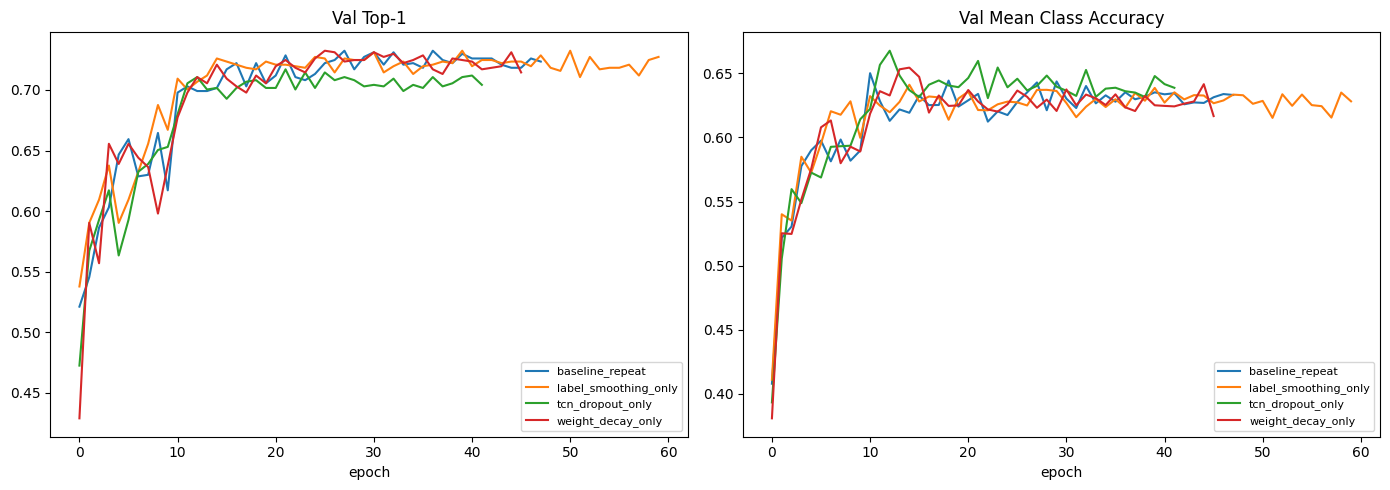

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, history in all_histories.items():
    axes[0].plot(history["val_top1"], label=name)
    axes[1].plot(history["val_mca"], label=name)
axes[0].set_title("Val Top-1"); axes[0].legend(fontsize=8)
axes[1].set_title("Val Mean Class Accuracy"); axes[1].legend(fontsize=8)
for ax in axes:
    ax.set_xlabel("epoch")
plt.tight_layout()
plt.savefig(os.path.join(OUT_ROOT, "ablation_curves.png"), dpi=200)
plt.show()


---

Read `baseline_repeat` first - compare it against `original_winning_run` in the table. The gap between those two numbers, from literally the same config on a different seed, is your noise floor. Anything the other three configs improve by less than that gap isn't a real, trustworthy improvement - it's within the range you'd see from randomness alone.